## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [4]:
YEAR = 2023
MONTH = 'August'
PERIOD = '1st'

In [5]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_{YEAR}-{MONTH}-{PERIOD}_filled.csv', encoding=enc)


In [6]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023-08-01,2023,8,2023-08-01,37.991999,23.654887,0.072597,-0.056274,-0.140735,0.056274,0.102353,-0.053480,-0.161769,0.053480,0.033199,0.012476,0.027588,0.012476,NaN,NaN,37.991999,23.654887,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,2023-07-31,37.950174,23.650108,348.910701,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.000000,0.000000
1,αγιας παρασκευης,αττικης,23.82642,38.00806,2023-08-01,2023,8,2023-08-01,38.009965,23.825567,0.191321,0.024308,-0.222122,-0.024308,0.194652,0.028120,-0.220625,-0.028120,0.022706,0.014833,0.016365,0.014833,NaN,NaN,38.009965,23.825567,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,2023-07-31,38.050174,23.850109,425.951674,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.000000,0.000000
2,αγιου δημητριου,αττικης,23.73031,37.93357,2023-08-01,2023,8,2023-08-01,37.933609,23.731244,0.117532,-0.028843,-0.179234,0.028843,0.098477,-0.034221,-0.159017,0.034221,0.022599,0.009434,0.018917,0.009434,NaN,NaN,37.933609,23.731244,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,2023-07-31,37.950174,23.750109,365.646401,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.000000,0.000000
3,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023-08-01,2023,8,2023-08-01,38.045898,23.713278,0.130143,-0.065602,-0.186687,0.065602,0.157629,-0.065827,-0.208062,0.065827,0.036587,0.016287,0.024380,0.016287,NaN,NaN,38.045898,23.713278,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,2023-07-31,38.050174,23.750109,437.278102,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.000000,0.000000
4,αγκιστριου,αττικης,23.34009,37.69503,2023-08-01,2023,8,2023-08-01,37.695555,23.340477,0.279617,-0.046090,-0.223027,0.046090,0.291183,-0.031676,-0.237061,0.031676,0.024057,0.052899,0.012071,0.052899,NaN,NaN,37.695555,23.340477,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,2023-07-31,37.650172,23.350107,485.607975,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.000664,0.000664


In [7]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [10]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [11]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023-08-01,2023,8,0.072597,-0.056274,-0.140735,0.056274,0.102353,-0.053480,-0.161769,0.053480,0.033199,0.012476,0.027588,0.012476,NaN,NaN,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,348.910701,0.000000,0.000000
1,αγιας παρασκευης,αττικης,23.82642,38.00806,2023-08-01,2023,8,0.191321,0.024308,-0.222122,-0.024308,0.194652,0.028120,-0.220625,-0.028120,0.022706,0.014833,0.016365,0.014833,NaN,NaN,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,425.951674,0.000000,0.000000
2,αγιου δημητριου,αττικης,23.73031,37.93357,2023-08-01,2023,8,0.117532,-0.028843,-0.179234,0.028843,0.098477,-0.034221,-0.159017,0.034221,0.022599,0.009434,0.018917,0.009434,NaN,NaN,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,365.646401,0.000000,0.000000
3,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023-08-01,2023,8,0.130143,-0.065602,-0.186687,0.065602,0.157629,-0.065827,-0.208062,0.065827,0.036587,0.016287,0.024380,0.016287,NaN,NaN,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,437.278102,0.000000,0.000000
4,αγκιστριου,αττικης,23.34009,37.69503,2023-08-01,2023,8,0.279617,-0.046090,-0.223027,0.046090,0.291183,-0.031676,-0.237061,0.031676,0.024057,0.052899,0.012071,0.052899,NaN,NaN,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,485.607975,0.000664,0.000664


In [12]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-08-01,αγιας βαρβαρας,αττικης,23.656970,37.992200,2023.0,8.0,0.072597,-0.056274,-0.140735,0.056274,0.102353,-0.053480,-0.161769,0.053480,0.033199,0.012476,0.027588,0.012476,NaN,NaN,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,348.910701,0.000000,0.000000
1,2023-08-01,αγιας παρασκευης,αττικης,23.826420,38.008060,2023.0,8.0,0.191321,0.024308,-0.222122,-0.024308,0.194652,0.028120,-0.220625,-0.028120,0.022706,0.014833,0.016365,0.014833,NaN,NaN,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,425.951674,0.000000,0.000000
2,2023-08-01,αγιου δημητριου,αττικης,23.730310,37.933570,2023.0,8.0,0.117532,-0.028843,-0.179234,0.028843,0.098477,-0.034221,-0.159017,0.034221,0.022599,0.009434,0.018917,0.009434,NaN,NaN,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,365.646401,0.000000,0.000000
3,2023-08-01,αγιων αναργυρων καματερου,αττικης,23.713410,38.047210,2023.0,8.0,0.130143,-0.065602,-0.186687,0.065602,0.157629,-0.065827,-0.208062,0.065827,0.036587,0.016287,0.024380,0.016287,NaN,NaN,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,437.278102,0.000000,0.000000
4,2023-08-01,αγκιστριου,αττικης,23.340090,37.695030,2023.0,8.0,0.279617,-0.046090,-0.223027,0.046090,0.291183,-0.031676,-0.237061,0.031676,0.024057,0.052899,0.012071,0.052899,NaN,NaN,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,485.607975,0.000664,0.000664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2023-08-01,φιλοθεης ψυχικου,αττικης,23.776280,38.014770,2023.0,8.0,0.270066,0.052220,-0.277910,-0.052220,0.241266,0.033742,-0.260575,-0.033742,0.028055,0.024144,0.020873,0.024144,NaN,NaN,14336.631579,14058.052632,14351.083333,13962.608696,14601.846154,14136.722222,14814.133333,14253.928571,437.278102,0.000000,0.000000
62,2023-08-01,φυλης,αττικης,23.688620,38.106703,2023.0,8.0,0.261451,-0.021141,-0.281693,0.021141,0.295244,0.000835,-0.296049,-0.000835,0.041412,0.041924,0.021443,0.041924,NaN,NaN,14286.856209,13919.959831,14262.083333,13867.802315,14500.012698,14007.878571,14697.305556,14082.353535,400.114421,0.000000,0.000000
63,2023-08-01,χαλανδριου,αττικης,23.809410,38.022260,2023.0,8.0,0.216582,0.039957,-0.243138,-0.039957,0.223762,0.039369,-0.247848,-0.039369,0.047232,0.033458,0.032985,0.033458,NaN,NaN,14348.000000,14057.578947,14377.500000,13986.142857,14647.666667,14128.588235,14793.333333,14171.142857,425.951674,0.000000,0.000000
64,2023-08-01,χαϊδαριου,αττικης,23.630840,38.009420,2023.0,8.0,0.276525,-0.059599,-0.261055,0.059599,0.280146,-0.032418,-0.259919,0.032418,0.025868,0.039354,0.012063,0.039354,NaN,NaN,14355.380952,14021.611111,14362.533333,13924.600000,14569.875000,14147.933333,14794.058824,14248.400000,439.846210,0.000000,0.000000


In [13]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [14]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [15]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [16]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [17]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [18]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [19]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [20]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

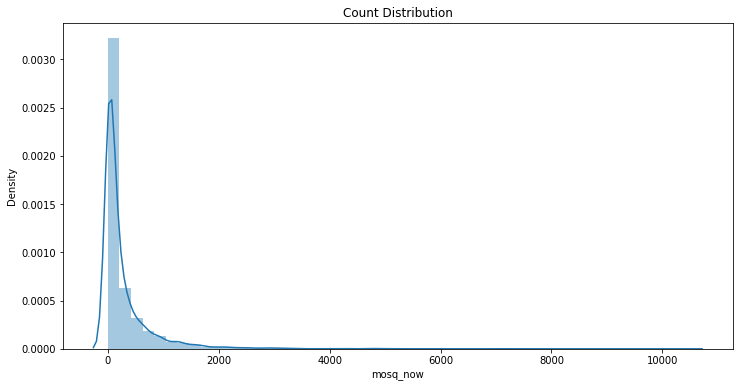

In [21]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [22]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

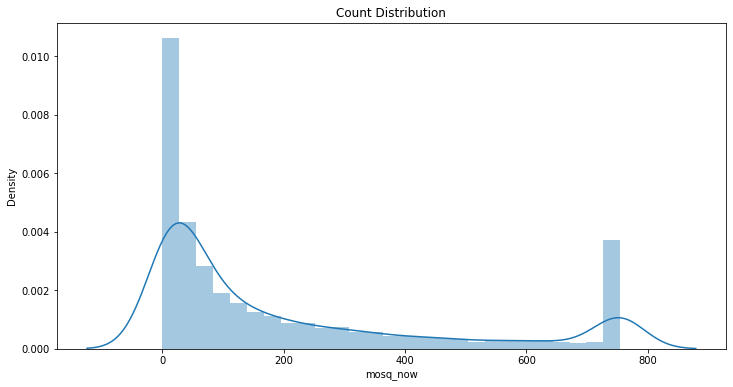

In [23]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

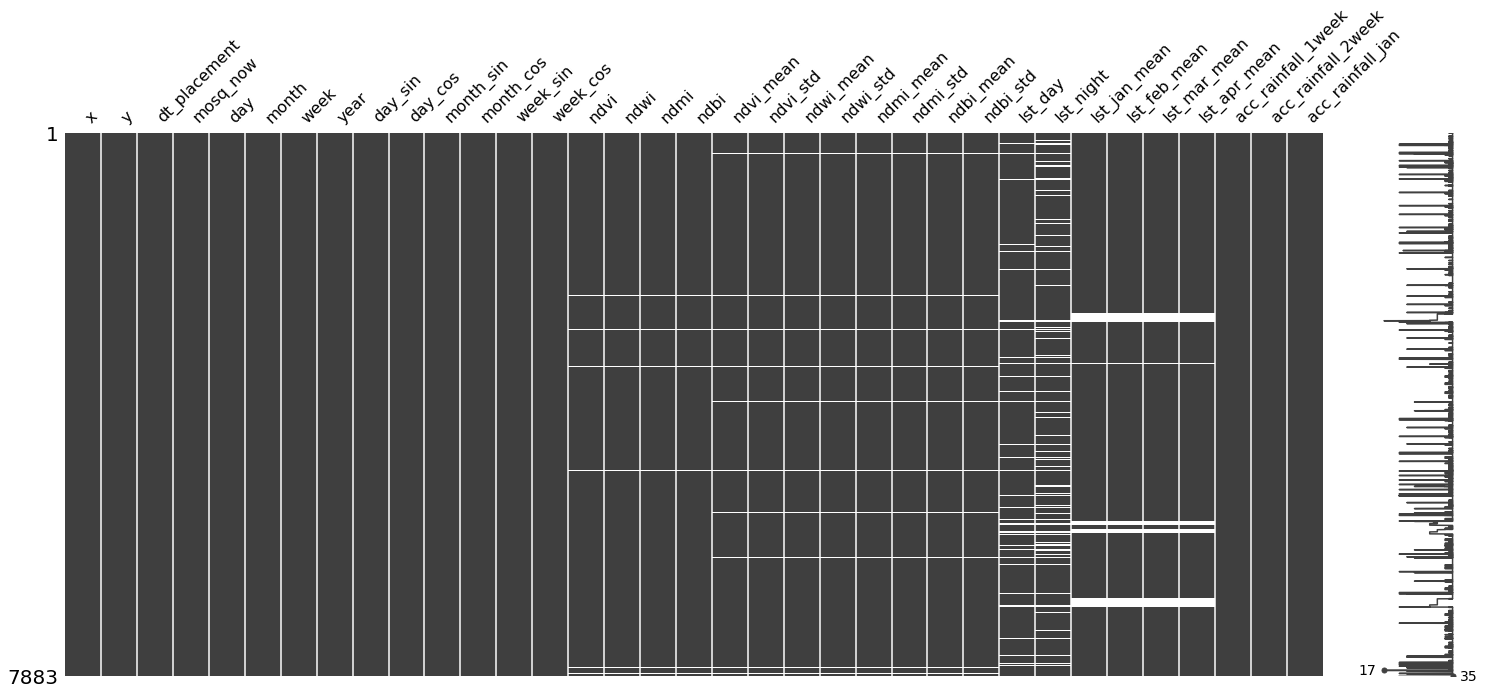

In [24]:
missingno.matrix(mosquito_data_nuts2)

In [25]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [26]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

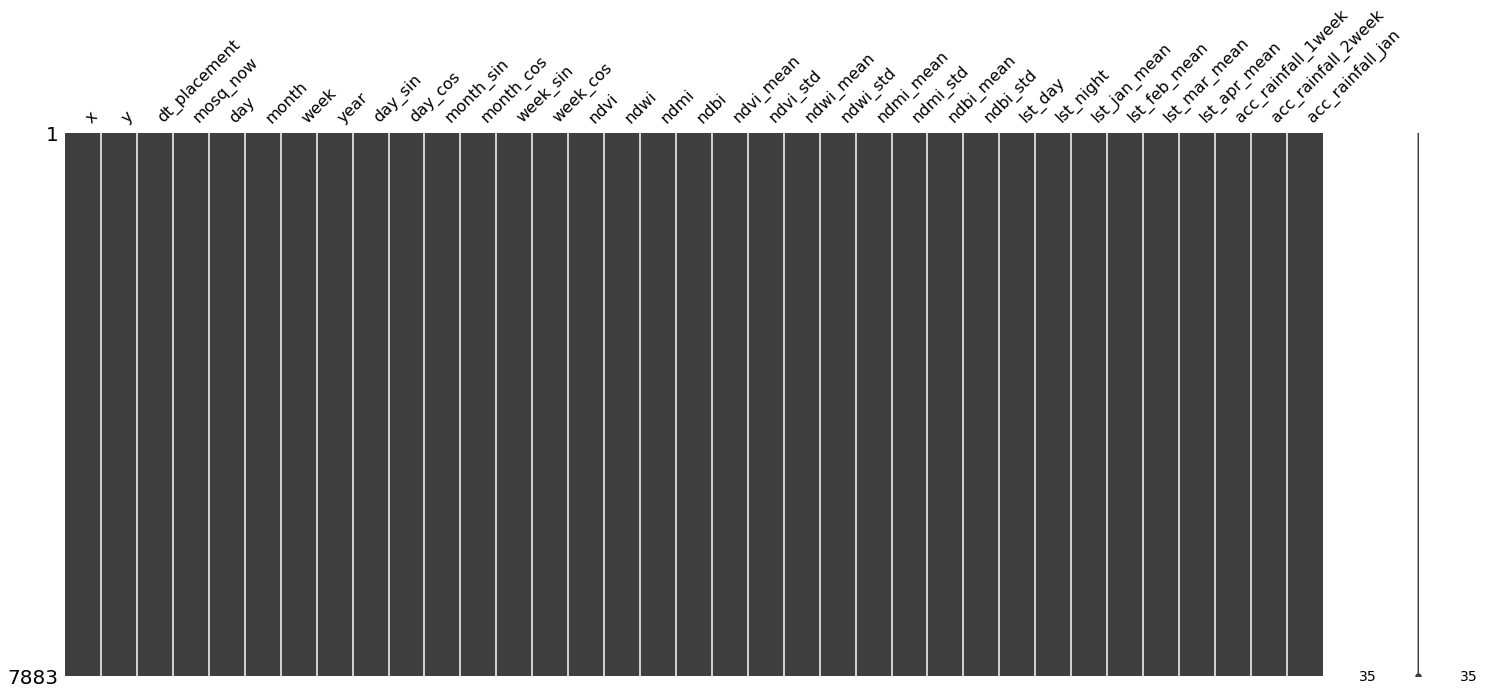

In [27]:
missingno.matrix(mosquito_data_nuts2)

In [28]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [29]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


In [30]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 20.97970 | Val Loss: 36.57492 | Train Acc: 2.884| Val Acc: 2.992
Epoch 002: | Train Loss: 18.92328 | Val Loss: 24.65612 | Train Acc: 2.314| Val Acc: 1.986
Epoch 003: | Train Loss: 18.37693 | Val Loss: 25.42813 | Train Acc: 2.180| Val Acc: 1.984
Epoch 004: | Train Loss: 18.06424 | Val Loss: 25.32123 | Train Acc: 2.131| Val Acc: 1.978
Epoch 005: | Train Loss: 17.70995 | Val Loss: 24.48845 | Train Acc: 2.084| Val Acc: 2.034
Epoch 006: | Train Loss: 17.64750 | Val Loss: 23.53974 | Train Acc: 2.052| Val Acc: 1.952
Epoch 007: | Train Loss: 17.11300 | Val Loss: 23.94428 | Train Acc: 2.000| Val Acc: 2.001
Epoch 008: | Train Loss: 17.12028 | Val Loss: 24.17328 | Train Acc: 2.000| Val Acc: 1.982
Epoch 009: | Train Loss: 17.00393 | Val Loss: 24.12685 | Train Acc: 1.996| Val Acc: 2.034
Epoch 010: | Train Loss: 16.74535 | Val Loss: 24.45439 | Train Acc: 1.967| Val Acc: 2.018
Epoch 011: | Train Loss: 16.74189 | Val Loss: 24.51347 | Train Acc: 1.971| Val Acc: 2.110
Epoch 012:

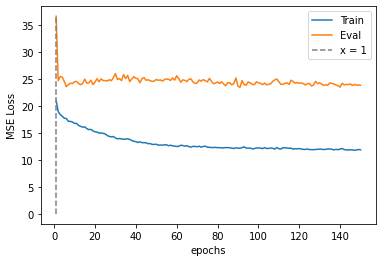

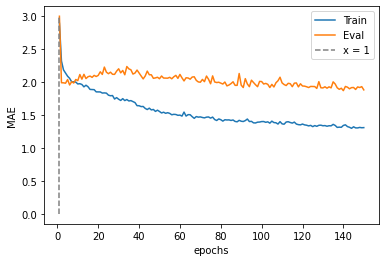

In [31]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [32]:
metrics(train, test, threshold=30)

MAE on train set:  142.68038640732348
min prediction: 1
max prediction: 1140

MAE on test set:  147.24171180819584
Error ⩽ 30: 22.22 %
min prediction: 1
max prediction: 998


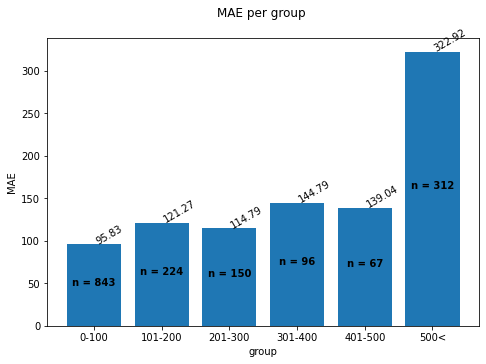

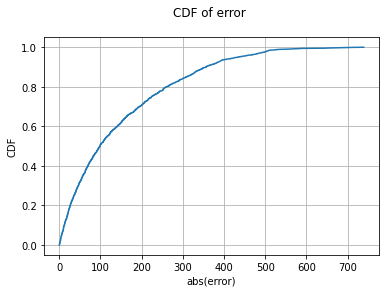

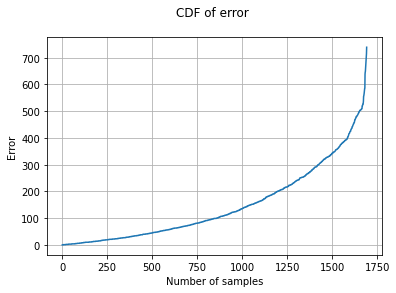

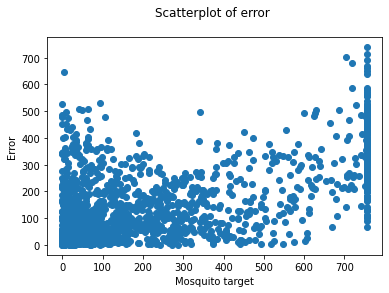

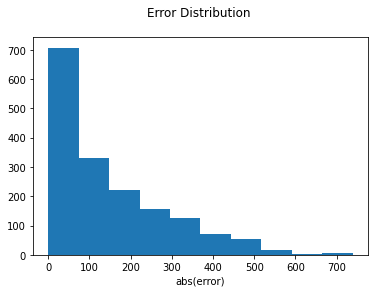

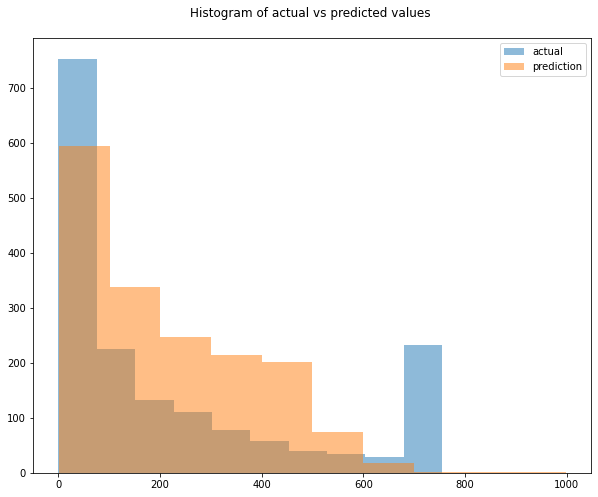

In [33]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.65934 | Val Loss: 3.68702 | Train Acc: 1.562| Val Acc: 1.633
Epoch 002: | Train Loss: 13.25053 | Val Loss: 5.33873 | Train Acc: 1.489| Val Acc: 2.633
Epoch 003: | Train Loss: 13.25172 | Val Loss: 4.16382 | Train Acc: 1.500| Val Acc: 1.633
Epoch 004: | Train Loss: 13.12455 | Val Loss: 5.34990 | Train Acc: 1.488| Val Acc: 2.633
Epoch 005: | Train Loss: 13.00071 | Val Loss: 6.63660 | Train Acc: 1.473| Val Acc: 2.633
Epoch 006: | Train Loss: 13.18408 | Val Loss: 8.07529 | Train Acc: 1.521| Val Acc: 2.633
Epoch 007: | Train Loss: 13.20124 | Val Loss: 6.94765 | Train Acc: 1.508| Val Acc: 2.633
Epoch 008: | Train Loss: 13.08649 | Val Loss: 6.67195 | Train Acc: 1.492| Val Acc: 2.633
Epoch 009: | Train Loss: 13.04639 | Val Loss: 6.12596 | Train Acc: 1.498| Val Acc: 2.633
Epoch 010: | Train Loss: 12.89742 | Val Loss: 5.54719 | Train Acc: 1.443| Val Acc: 2.633
Epoch 011: | Train Loss: 12.86096 | Val Loss: 7.35999 | Train Acc: 1.454| Val Acc: 2.633
Epoch 012: | Train Lo

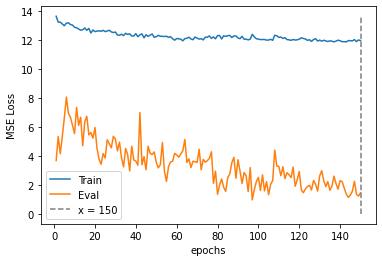

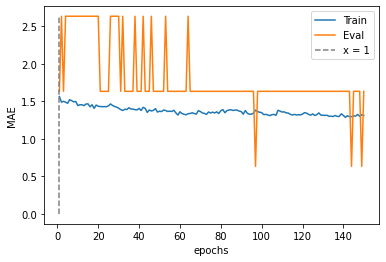

In [34]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [35]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [36]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [37]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [38]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [39]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [40]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

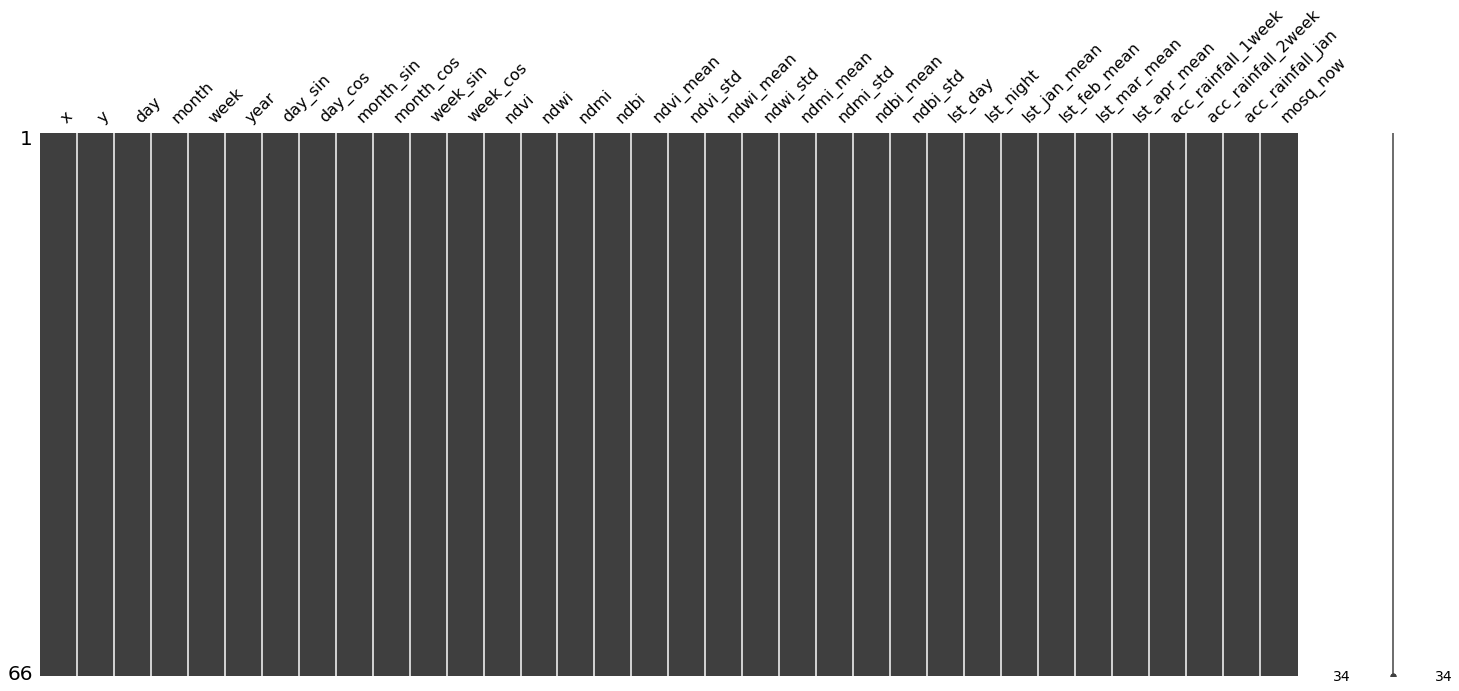

In [41]:
missingno.matrix(dataset_mamoth)

In [42]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [43]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [44]:
predictions = give_predictions(model, dataset_mamoth)

In [45]:
mosqutio_predictions['mosq_pred'] = predictions

In [46]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,23.656970,37.992200,2023-08-01,43
1,23.826420,38.008060,2023-08-01,32
2,23.730310,37.933570,2023-08-01,37
3,23.713410,38.047210,2023-08-01,36
4,23.340090,37.695030,2023-08-01,35
...,...,...,...,...
61,23.776280,38.014770,2023-08-01,32
62,23.688620,38.106703,2023-08-01,26
63,23.809410,38.022260,2023-08-01,30
64,23.630840,38.009420,2023-08-01,31


In [47]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_{YEAR}-{MONTH}-{PERIOD}.csv', index = False)